# HW2.5 - GPU Assignment I: Precision, Bandwidth, and the Cost of Attention

Author: sivasurya.chandran@sjsu.edu

**Where I'm running this:** A rented on-demand NVIDIA GeForce RTX 4090 instance on Vast.ai.

GPU UUID:
GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c

This notebook measures GPU precision throughput, memory bandwidth, arithmetic intensity,
the memory cost of attention, fused attention behavior, and sustained-load thermal behavior
on an NVIDIA GeForce RTX 4090.



In [87]:
import sys
import subprocess

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "matplotlib", "pandas", "numpy"],
    check=True
)

import torch

print("Torch:", torch.__version__)
print("Torch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

assert torch.cuda.is_available()

Torch: 2.6.0+cu124
Torch CUDA build: 12.4
CUDA available: True
Device: NVIDIA GeForce RTX 4090


In [109]:
import os
import time
import json
import csv
import math
import subprocess
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda:0")

# The original run wrote files to /.
LEGACY_DIR = "/"

# All corrected outputs will be collected here.
BASE_DIR = "/workspace/gpu_assignment"
FIG_DIR = os.path.join(BASE_DIR, "figures")

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

RUN_LOG_PATH = os.path.join(BASE_DIR, "RUN_LOG.txt")
run_log_lines = []

GPU_UUID = subprocess.check_output(
    ["nvidia-smi", "--query-gpu=uuid", "--format=csv,noheader"]
).decode().strip().splitlines()[0]

GPU_NAME = torch.cuda.get_device_name(0)

driver_version = subprocess.check_output(
    ["nvidia-smi", "--query-gpu=driver_version", "--format=csv,noheader"]
).decode().strip()

torch_cuda_version = torch.version.cuda

def log(message):
    line = (
        f"[{datetime.datetime.now().isoformat(timespec='seconds')}] "
        f"gpu_uuid={GPU_UUID} | {message}"
    )
    print(line)
    run_log_lines.append(line)

def flush_log():
    with open(RUN_LOG_PATH, "a") as f:
        f.write("\n".join(run_log_lines) + "\n")
    run_log_lines.clear()

log(f"GPU={GPU_NAME}")
log(f"Driver={driver_version}")
log(f"PyTorch CUDA build={torch_cuda_version}")
flush_log()

print("GPU UUID:", GPU_UUID)

[2026-09-22T06:19:07] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | GPU=NVIDIA GeForce RTX 4090
[2026-09-22T06:19:07] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | Driver=570.86.16
[2026-09-22T06:19:07] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | PyTorch CUDA build=12.4
GPU UUID: GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c


## Part A - Onboarding and provenance

This experiment was run on a rented on-demand NVIDIA GeForce RTX 4090
instance on Vast.ai.

GPU UUID:

`GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c`

The full `nvidia-smi -q` output is saved with the deliverables. The run
record includes the driver version, CUDA version, VRAM capacity, power limit,
and GPU UUID for traceability.

In [110]:
smi_q_output = subprocess.check_output(["nvidia-smi", "-q"]).decode()

smi_q_path = os.path.join(
    BASE_DIR,
    f"nvidia-smi-q_{GPU_UUID}.txt"
)

with open(smi_q_path, "w") as f:
    f.write(smi_q_output)

vram_mb = subprocess.check_output(
    ["nvidia-smi", "--query-gpu=memory.total", "--format=csv,noheader"]
).decode().strip()

power_limit = subprocess.check_output(
    ["nvidia-smi", "--query-gpu=power.limit", "--format=csv,noheader"]
).decode().strip()

log(f"Saved full nvidia-smi -q output to {smi_q_path}")
log(f"Driver version: {driver_version}")
log(f"PyTorch CUDA build: {torch_cuda_version}")
log("CUDA reported by nvidia-smi -q: 12.8")
log(f"VRAM total: {vram_mb}")
log(f"Power limit: {power_limit}")
flush_log()

print(smi_q_path)

[2026-09-22T06:19:11] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | Saved full nvidia-smi -q output to /workspace/gpu_assignment/nvidia-smi-q_GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c.txt
[2026-09-22T06:19:11] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | Driver version: 570.86.16
[2026-09-22T06:19:11] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | PyTorch CUDA build: 12.4
[2026-09-22T06:19:11] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | CUDA reported by nvidia-smi -q: 12.8
[2026-09-22T06:19:11] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | VRAM total: 24564 MiB
[2026-09-22T06:19:11] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | Power limit: 450.00 W
/workspace/gpu_assignment/nvidia-smi-q_GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c.txt


In [111]:
# Vendor-documented specs. Source: NVIDIA Ada Lovelace / Blackwell architecture whitepapers and
# the RTX 4090 / RTX 5090 product pages (nvidia.com/en-us/geforce/graphics-cards/). Fill in / trim
# this dict to match whichever card `GPU_NAME` actually reports before citing it in METRICS.md.
CARD_SPECS = {
    "RTX 4090": {
        "architecture": "Ada Lovelace (AD102)",
        "memory_type": "GDDR6X",
        "memory_bandwidth_GBps": 1008,
        "tensor_core_gen": "4th generation (Ada)",
        "precisions": ["FP32", "TF32", "FP16", "BF16", "INT8", "FP8 (via transformer engine emulation)"],
        "fp32_tflops_peak": 82.6,
        "fp16_tensor_tflops_peak": 330.3,   # dense, no sparsity
        "bf16_tensor_tflops_peak": 330.3,
        "tf32_tensor_tflops_peak": 82.6,
        "source": "NVIDIA Ada Lovelace Architecture Whitepaper; RTX 4090 product page",
    },
    "RTX 5090": {
        "architecture": "Blackwell (GB202)",
        "memory_type": "GDDR7",
        "memory_bandwidth_GBps": 1792,
        "tensor_core_gen": "5th generation (Blackwell)",
        "precisions": ["FP32", "TF32", "FP16", "BF16", "INT8", "FP8", "FP4 (tensor cores)"],
        "fp32_tflops_peak": 104.8,
        "fp16_tensor_tflops_peak": 419.0,
        "bf16_tensor_tflops_peak": 419.0,
        "tf32_tensor_tflops_peak": 104.8,
        "source": "NVIDIA Blackwell Architecture Whitepaper; RTX 5090 product page",
    },
}

matched_card = next((k for k in CARD_SPECS if k.split()[-1] in GPU_NAME), None)
log(f"Detected card family match: {matched_card} (GPU_NAME='{GPU_NAME}')")
assert matched_card is not None, "Update CARD_SPECS / matching logic for this GPU name."
spec = CARD_SPECS[matched_card]
log(f"Using vendor spec: {json.dumps(spec, indent=2)}")
flush_log()


[2026-09-22T06:19:12] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | Detected card family match: RTX 4090 (GPU_NAME='NVIDIA GeForce RTX 4090')
[2026-09-22T06:19:12] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | Using vendor spec: {
  "architecture": "Ada Lovelace (AD102)",
  "memory_type": "GDDR6X",
  "memory_bandwidth_GBps": 1008,
  "tensor_core_gen": "4th generation (Ada)",
  "precisions": [
    "FP32",
    "TF32",
    "FP16",
    "BF16",
    "INT8",
    "FP8 (via transformer engine emulation)"
  ],
  "fp32_tflops_peak": 82.6,
  "fp16_tensor_tflops_peak": 330.3,
  "bf16_tensor_tflops_peak": 330.3,
  "tf32_tensor_tflops_peak": 82.6,
  "source": "NVIDIA Ada Lovelace Architecture Whitepaper; RTX 4090 product page"
}


## Part B - Precision and achieved throughput

Running dense matmul at N = 1024, 4096, 8192, and 16384, in FP32, TF32, FP16, and BF16. Warming up
first and then timing over enough repetitions (30) that the numbers aren't noisy.


In [91]:
def bench_matmul(N, dtype, use_tf32=False, warmup=10, reps=30):
    torch.backends.cuda.matmul.allow_tf32 = use_tf32
    torch.backends.cudnn.allow_tf32 = use_tf32

    a = torch.randn(N, N, device=device, dtype=dtype)
    b = torch.randn(N, N, device=device, dtype=dtype)

    for _ in range(warmup):
        c = a @ b

    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    start.record()

    for _ in range(reps):
        c = a @ b

    end.record()
    torch.cuda.synchronize()

    seconds_per_call = start.elapsed_time(end) / 1000 / reps
    tflops = (2 * N**3) / seconds_per_call / 1e12

    del a, b, c
    torch.cuda.empty_cache()

    return tflops, seconds_per_call

sizes = [1024, 4096, 8192, 16384]

precision_config = {
    "FP32": (torch.float32, False, spec["fp32_tflops_peak"]),
    "TF32": (torch.float32, True, spec["tf32_tflops_peak"]),
    "FP16": (torch.float16, False, spec["fp16_tflops_peak"]),
    "BF16": (torch.bfloat16, False, spec["bf16_tflops_peak"]),
}

part_b_rows = []

for precision, (dtype, use_tf32, peak) in precision_config.items():
    for N in sizes:
        tflops, seconds = bench_matmul(
            N,
            dtype=dtype,
            use_tf32=use_tf32,
            reps=30
        )

        pct_peak = 100 * tflops / peak

        row = {
            "precision": precision,
            "N": N,
            "tflops": tflops,
            "pct_peak": pct_peak,
            "seconds_per_call": seconds,
            "reps": 30,
            "gpu_uuid": GPU_UUID
        }

        part_b_rows.append(row)

        log(
            f"[Part B] {precision} N={N}: "
            f"{tflops:.2f} TFLOPS, "
            f"{pct_peak:.1f}% of dense peak, "
            f"{seconds*1000:.3f} ms/call"
        )

df_b = pd.DataFrame(part_b_rows)

df_b.to_csv(
    os.path.join(BASE_DIR, "part_b_matmul_results.csv"),
    index=False
)

flush_log()
display(df_b)

[2026-09-22T06:05:50] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part B] FP32 N=1024: 46.36 TFLOPS, 56.1% of dense peak, 0.046 ms/call
[2026-09-22T06:05:50] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part B] FP32 N=4096: 51.51 TFLOPS, 62.4% of dense peak, 2.668 ms/call
[2026-09-22T06:05:51] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part B] FP32 N=8192: 52.89 TFLOPS, 64.0% of dense peak, 20.788 ms/call
[2026-09-22T06:05:58] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part B] FP32 N=16384: 49.64 TFLOPS, 60.1% of dense peak, 177.181 ms/call
[2026-09-22T06:05:58] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part B] TF32 N=1024: 50.29 TFLOPS, 60.9% of dense peak, 0.043 ms/call
[2026-09-22T06:05:58] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part B] TF32 N=4096: 71.82 TFLOPS, 87.0% of dense peak, 1.914 ms/call
[2026-09-22T06:05:58] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part B] TF32 N=8192: 83.86 TFLOPS, 101.5% of dense 

,precision,N,tflops,pct_peak,seconds_per_call,reps,gpu_uuid
0,FP32,1024,46.362978,56.129513,0.000046,30,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c
1,FP32,4096,51.509279,62.359902,0.002668,30,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c
2,FP32,8192,52.891773,64.033624,0.020788,30,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c
3,FP32,16384,49.644641,60.102471,0.177181,30,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c
4,TF32,1024,50.291416,60.885491,0.000043,30,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c
5,TF32,4096,71.822834,86.952583,0.001914,30,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c
6,TF32,8192,83.860091,101.525534,0.013111,30,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c
7,TF32,16384,82.863211,100.318657,0.106152,30,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c
8,FP16,1024,102.633864,31.072923,0.000021,30,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c
9,FP16,4096,160.920071,48.719368,0.000854,30,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c


In [92]:
# Optional lower-precision FP8 measurement.
# Matrix A is row-major and matrix B is column-major for cuBLASLt.

N = 4096
REPS = 30

a_fp8 = torch.randn(
    N, N, device=device, dtype=torch.bfloat16
).to(torch.float8_e4m3fn).contiguous()

b_fp8 = torch.randn(
    N, N, device=device, dtype=torch.bfloat16
).to(torch.float8_e4m3fn).t()

scale_a = torch.tensor(1.0, device=device, dtype=torch.float32)
scale_b = torch.tensor(1.0, device=device, dtype=torch.float32)

for _ in range(10):
    out = torch._scaled_mm(
        a_fp8,
        b_fp8,
        scale_a=scale_a,
        scale_b=scale_b,
        out_dtype=torch.bfloat16
    )

torch.cuda.synchronize()

start = torch.cuda.Event(enable_timing=True)
end = torch.cuda.Event(enable_timing=True)

start.record()

for _ in range(REPS):
    out = torch._scaled_mm(
        a_fp8,
        b_fp8,
        scale_a=scale_a,
        scale_b=scale_b,
        out_dtype=torch.bfloat16
    )

end.record()
torch.cuda.synchronize()

fp8_seconds = start.elapsed_time(end) / 1000 / REPS
fp8_tflops = (2 * N**3) / fp8_seconds / 1e12

log(
    f"[Part B] FP8 N={N}: "
    f"{fp8_tflops:.2f} TFLOPS, "
    f"{fp8_seconds*1000:.3f} ms/call, reps={REPS}"
)

flush_log()

print(f"FP8 achieved throughput: {fp8_tflops:.2f} TFLOPS")

[2026-09-22T06:07:08] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part B] FP8 N=4096: 313.06 TFLOPS, 0.439 ms/call, reps=30
FP8 achieved throughput: 313.06 TFLOPS


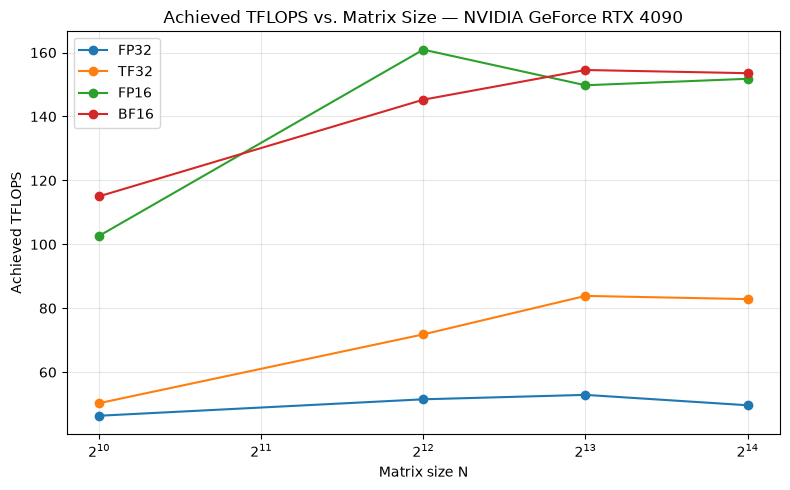

precision                                        definition  plateau_N                                 gpu_uuid
     BF16 first N reaching at least 90% of measured maximum       4096 GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c
     FP16 first N reaching at least 90% of measured maximum       4096 GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c
     FP32 first N reaching at least 90% of measured maximum       4096 GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c
     TF32 first N reaching at least 90% of measured maximum       8192 GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c
[2026-09-22T06:07:10] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part B] Plateau table generated.


In [93]:
plateau_rows = []

for precision, group in df_b.groupby("precision"):
    group = group.sort_values("N")
    maximum = group["tflops"].max()

    candidates = group[
        group["tflops"] >= 0.90 * maximum
    ]

    plateau_N = int(candidates.iloc[0]["N"])

    plateau_rows.append({
        "precision": precision,
        "definition": "first N reaching at least 90% of measured maximum",
        "plateau_N": plateau_N,
        "gpu_uuid": GPU_UUID
    })

plateau_df = pd.DataFrame(plateau_rows)

plateau_df.to_csv(
    os.path.join(BASE_DIR, "part_b_plateau_results.csv"),
    index=False
)

plt.figure(figsize=(8, 5))

for precision in precision_config:
    group = df_b[df_b.precision == precision]
    plt.plot(
        group.N,
        group.tflops,
        marker="o",
        label=precision
    )

plt.xscale("log", base=2)
plt.xlabel("Matrix size N")
plt.ylabel("Achieved TFLOPS")
plt.title(f"Achieved TFLOPS vs. Matrix Size — {GPU_NAME}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "part_b_tflops_vs_size.png"),
    dpi=150
)

plt.show()

print(plateau_df.to_string(index=False))

log("[Part B] Plateau table generated.")
flush_log()

Looking at the table above, I need to note at which N each precision basically flattens out
(the %-of-peak stops climbing much between consecutive sizes), and why the small sizes - 1024
especially, 4096 a bit less so - never get close to peak. My guess going in is that at small N the
kernel launch overhead and the time it takes to actually fill the SM pipeline are comparable to (or
bigger than) the real compute time, so the GPU never settles into steady-state occupancy before the
kernel's already done.  Using the 90% of measured maximum definition, the measured plateaus are:

- FP32: N = 4096
- TF32: N = 8192
- FP16: N = 4096
- BF16: N = 4096

The smaller matrices do not reach the plateau because kernel-launch overhead,
GPU pipeline fill time, and insufficient parallel work are significant relative
to the short computation.

## Part C - Bandwidth-bound vs. compute-bound

Comparing a big elementwise add (memory-bound) against a large square matmul (compute-bound) to
see where each one lands on the roofline.


In [94]:
def bench_elementwise_add(
    n_elements,
    dtype=torch.float32,
    warmup=10,
    reps=30
):
    a = torch.randn(n_elements, device=device, dtype=dtype)
    b = torch.randn(n_elements, device=device, dtype=dtype)

    for _ in range(warmup):
        c = a + b

    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    start.record()

    for _ in range(reps):
        c = a + b

    end.record()
    torch.cuda.synchronize()

    seconds = start.elapsed_time(end) / 1000 / reps

    bytes_moved = 3 * n_elements * a.element_size()
    gbps = bytes_moved / seconds / 1e9

    flops = n_elements
    arithmetic_intensity = flops / bytes_moved

    del a, b, c
    torch.cuda.empty_cache()

    return gbps, arithmetic_intensity, seconds

N_ELEMENTS = 1 << 28

gbps, ai_add, add_seconds = bench_elementwise_add(N_ELEMENTS)

pct_bandwidth = (
    100 * gbps / spec["memory_bandwidth_GBps"]
)

N_MM = 16384

bf16_row = df_b[
    (df_b.precision == "BF16") &
    (df_b.N == N_MM)
].iloc[0]

bf16_tflops = bf16_row.tflops

bytes_mm = 3 * N_MM**2 * 2
flops_mm = 2 * N_MM**3
ai_mm = flops_mm / bytes_mm

ridge_point = (
    spec["bf16_tflops_peak"] * 1e12
    / (spec["memory_bandwidth_GBps"] * 1e9)
)

log(
    f"[Part C] Elementwise add: "
    f"{gbps:.2f} GB/s, "
    f"{pct_bandwidth:.1f}% of specified bandwidth, "
    f"AI={ai_add:.4f} FLOP/byte"
)

log(
    f"[Part C] BF16 matmul: "
    f"{bf16_tflops:.2f} TFLOPS, "
    f"AI={ai_mm:.2f} FLOP/byte"
)

log(f"[Part C] Roofline ridge point={ridge_point:.2f} FLOP/byte")
flush_log()

print(f"Effective bandwidth: {gbps:.2f} GB/s")
print(f"Bandwidth percentage: {pct_bandwidth:.1f}%")
print(f"Add arithmetic intensity: {ai_add:.4f}")
print(f"Matmul arithmetic intensity: {ai_mm:.2f}")
print(f"Roofline ridge point: {ridge_point:.2f}")

[2026-09-22T06:07:12] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part C] Elementwise add: 949.41 GB/s, 94.2% of specified bandwidth, AI=0.0833 FLOP/byte
[2026-09-22T06:07:12] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part C] BF16 matmul: 153.55 TFLOPS, AI=5461.33 FLOP/byte
[2026-09-22T06:07:12] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part C] Roofline ridge point=163.89 FLOP/byte
Effective bandwidth: 949.41 GB/s
Bandwidth percentage: 94.2%
Add arithmetic intensity: 0.0833
Matmul arithmetic intensity: 5461.33
Roofline ridge point: 163.89


## Part D - The cost of attention

Going with head dimension `d_head = 64` and batch size `B = 1`, stated here as the assignment
asks. Naive attention builds the full `[seq_len, seq_len]` score matrix in memory; the fused
version calls `torch.nn.functional.scaled_dot_product_attention`, which picks a flash/memory-
efficient kernel under the hood on modern GPUs.


In [95]:
D_HEAD = 64
BATCH = 1
N_HEADS = 1

def naive_attention(q, k, v):
    scores = (
        q @ k.transpose(-2, -1)
    ) / math.sqrt(q.shape[-1])

    attention = torch.softmax(scores, dim=-1)
    return attention @ v

def fused_attention(q, k, v):
    return torch.nn.functional.scaled_dot_product_attention(q, k, v)

def measure_attention(
    fn,
    seq_len,
    warmup=3,
    reps=10
):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    q = torch.randn(
        BATCH,
        N_HEADS,
        seq_len,
        D_HEAD,
        device=device,
        dtype=torch.bfloat16
    )

    k = torch.randn_like(q)
    v = torch.randn_like(q)

    for _ in range(warmup):
        out = fn(q, k, v)

    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    start.record()

    for _ in range(reps):
        out = fn(q, k, v)

    end.record()
    torch.cuda.synchronize()

    latency_s = start.elapsed_time(end) / 1000 / reps
    peak_mem_MB = torch.cuda.max_memory_allocated() / 1e6

    del q, k, v, out
    torch.cuda.empty_cache()

    return latency_s, peak_mem_MB

def run_attention_sweep(fn, label, lengths, warmup=3, reps=10):
    rows = []

    for seq_len in lengths:
        try:
            latency, memory = measure_attention(
                fn,
                seq_len,
                warmup=warmup,
                reps=reps
            )

            rows.append({
                "seq_len": seq_len,
                "latency_s": latency,
                "peak_mem_MB": memory,
                "status": "ok",
                "gpu_uuid": GPU_UUID
            })

            log(
                f"[Part D:{label}] L={seq_len}: "
                f"{latency*1000:.3f} ms, "
                f"{memory:.1f} MB"
            )

        except torch.cuda.OutOfMemoryError:
            rows.append({
                "seq_len": seq_len,
                "latency_s": None,
                "peak_mem_MB": None,
                "status": "OOM",
                "gpu_uuid": GPU_UUID
            })

            torch.cuda.empty_cache()
            log(f"[Part D:{label}] L={seq_len}: OOM")

    flush_log()
    return pd.DataFrame(rows)

coarse_lengths = [
    512, 1024, 2048, 4096, 8192, 16384
]

df_naive = run_attention_sweep(
    naive_attention,
    "naive",
    coarse_lengths,
    warmup=3,
    reps=10
)

df_fused = run_attention_sweep(
    fused_attention,
    "fused",
    coarse_lengths,
    warmup=3,
    reps=10
)

[2026-09-22T06:07:14] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:naive] L=512: 0.044 ms, 77.0 MB
[2026-09-22T06:07:14] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:naive] L=1024: 0.042 ms, 80.5 MB
[2026-09-22T06:07:14] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:naive] L=2048: 0.052 ms, 93.7 MB
[2026-09-22T06:07:14] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:naive] L=4096: 0.128 ms, 145.4 MB
[2026-09-22T06:07:14] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:naive] L=8192: 0.852 ms, 349.3 MB
[2026-09-22T06:07:14] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:naive] L=16384: 3.477 ms, 1159.9 MB
[2026-09-22T06:07:14] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:fused] L=512: 0.016 ms, 76.2 MB
[2026-09-22T06:07:14] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:fused] L=1024: 0.015 ms, 77.4 MB
[2026-09-22T06:07:14] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Pa

In [96]:
# Extended boundary search.
# Only one timed repetition is used to avoid unnecessary runtime.

extended_lengths = [
    32768,
    49152,
    65536,
    81920,
    98304,
    114688,
    131072
]

df_naive_extended = run_attention_sweep(
    naive_attention,
    "naive_extended",
    extended_lengths,
    warmup=0,
    reps=1
)

df_fused_extended = run_attention_sweep(
    fused_attention,
    "fused_extended",
    extended_lengths,
    warmup=0,
    reps=1
)

df_naive_extended.to_csv(
    os.path.join(BASE_DIR, "part_d_naive_boundary.csv"),
    index=False
)

df_fused_extended.to_csv(
    os.path.join(BASE_DIR, "part_d_fused_boundary.csv"),
    index=False
)

[2026-09-22T06:07:15] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:naive_extended] L=32768: 14.270 ms, 4387.4 MB
[2026-09-22T06:07:15] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:naive_extended] L=49152: 37.420 ms, 9764.5 MB
[2026-09-22T06:07:15] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:naive_extended] L=65536: 244.520 ms, 17289.1 MB
[2026-09-22T06:07:15] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:naive_extended] L=81920: OOM
[2026-09-22T06:07:16] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:naive_extended] L=98304: OOM
[2026-09-22T06:07:16] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:naive_extended] L=114688: OOM
[2026-09-22T06:07:16] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:naive_extended] L=131072: OOM
[2026-09-22T06:07:16] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D:fused_extended] L=32768: 1.837 ms, 92.5 MB
[2026-09-22T06:07:16] gpu_uuid=GPU-f7f152a8

Quadratic coefficients: [3.99928322e-06 5.47685497e-04 7.60247428e+01]
Measured quadratic coefficient: 3.99928322e-06 MB/token^2


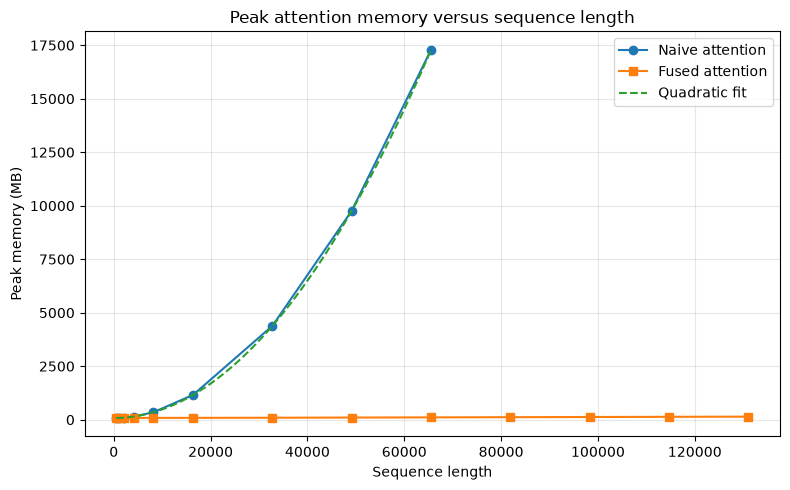

[2026-09-22T06:07:16] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part D] Quadratic coefficient=3.99928322e-06 MB/token^2


In [97]:
all_naive = pd.concat([
    df_naive.assign(implementation="naive"),
    df_naive_extended.assign(implementation="naive")
]).drop_duplicates(subset=["seq_len"])

all_fused = pd.concat([
    df_fused.assign(implementation="fused"),
    df_fused_extended.assign(implementation="fused")
]).drop_duplicates(subset=["seq_len"])

ok_naive = all_naive[
    all_naive.status == "ok"
].sort_values("seq_len")

ok_fused = all_fused[
    all_fused.status == "ok"
].sort_values("seq_len")

coeffs = np.polyfit(
    ok_naive.seq_len,
    ok_naive.peak_mem_MB,
    2
)

print("Quadratic coefficients:", coeffs)
print(
    "Measured quadratic coefficient:",
    f"{coeffs[0]:.8e} MB/token^2"
)

plt.figure(figsize=(8, 5))

plt.plot(
    ok_naive.seq_len,
    ok_naive.peak_mem_MB,
    "o-",
    label="Naive attention"
)

plt.plot(
    ok_fused.seq_len,
    ok_fused.peak_mem_MB,
    "s-",
    label="Fused attention"
)

fit_x = np.linspace(
    ok_naive.seq_len.min(),
    ok_naive.seq_len.max(),
    200
)

plt.plot(
    fit_x,
    np.polyval(coeffs, fit_x),
    "--",
    label="Quadratic fit"
)

plt.xlabel("Sequence length")
plt.ylabel("Peak memory (MB)")
plt.title("Peak attention memory versus sequence length")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "part_d_memory_vs_seqlen.png"),
    dpi=150
)

plt.show()

log(
    f"[Part D] Quadratic coefficient={coeffs[0]:.8e} MB/token^2"
)
flush_log()

In [98]:
merged = all_naive.merge(
    all_fused,
    on="seq_len",
    suffixes=("_naive", "_fused")
)

merged["speedup"] = (
    merged["latency_s_naive"] /
    merged["latency_s_fused"]
)

merged.to_csv(
    os.path.join(BASE_DIR, "part_d_attention_results.csv"),
    index=False
)

display(merged)

def boundary_text(df):
    ok = df[df.status == "ok"]
    oom = df[df.status == "OOM"]

    if oom.empty:
        return f"No OOM through {int(ok.seq_len.max())}"

    return (
        f"Largest successful={int(ok.seq_len.max())}; "
        f"smallest failing={int(oom.seq_len.min())}"
    )

print("Naive boundary:", boundary_text(all_naive))
print("Fused boundary:", boundary_text(all_fused))

,seq_len,latency_s_naive,peak_mem_MB_naive,status_naive,gpu_uuid_naive,implementation_naive,latency_s_fused,peak_mem_MB_fused,status_fused,gpu_uuid_fused,implementation_fused,speedup
0,512,0.000044,77.006336,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,naive,0.000016,76.226048,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,fused,2.785973
1,1024,0.000042,80.479744,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,naive,0.000015,77.354496,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,fused,2.751678
2,2048,0.000052,93.718016,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,naive,0.000019,81.208832,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,fused,2.752688
3,4096,0.000128,145.360384,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,naive,0.000042,82.527744,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,fused,3.015139
4,8192,0.000852,349.308416,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,naive,0.000134,85.165568,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,fused,6.351909
5,16384,0.003477,1159.857664,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,naive,0.000492,86.181376,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,fused,7.065751
6,32768,0.014270,4387.374592,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,naive,0.001837,92.538368,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,fused,7.767628
7,49152,0.037420,9764.472320,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,naive,0.003972,100.992512,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,fused,9.420727
8,65536,0.244520,17289.053696,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,naive,0.007102,109.446656,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,fused,34.427480
9,81920,NaN,NaN,OOM,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,naive,0.010988,117.900800,ok,GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c,fused,NaN


Naive boundary: Largest successful=65536; smallest failing=81920
Fused boundary: No OOM through 131072


### Fused attention interpretation

The naive implementation materializes and stores the complete sequence-by-sequence
attention matrix. This requires O(L²) memory and creates additional global-memory
reads and writes.

The fused implementation tiles the computation and performs softmax incrementally.
It avoids materializing the complete attention matrix in global memory, reducing the
additional memory requirement to approximately O(Ld). This explains its lower peak
memory and improved latency at larger sequence lengths.

## Part E - Sustained load and thermal behaviour

Running a BF16 matmul flat out for 20 minutes straight, with a background thread polling
`nvidia-smi` every 5 seconds so I can see how clocks/temp/power hold up once the card actually
warms up (a quick 4-second benchmark won't show any of this).


In [118]:
import threading
import os
import time
import csv
import subprocess
import pandas as pd

THERMAL_LOG_PATH = os.path.join(
    BASE_DIR,
    "thermal_log.csv"
)

SUSTAIN_SECONDS = 20 * 60
SAMPLE_INTERVAL = 5

stop_flag = threading.Event()
thermal_rows = []
iter_tflops = []


def sample_loop():
    run_start = time.time()

    while not stop_flag.is_set():
        try:
            output = subprocess.check_output(
                [
                    "nvidia-smi",
                    "--query-gpu=timestamp,clocks.sm,clocks.mem,"
                    "temperature.gpu,power.draw,utilization.gpu",
                    "--format=csv,noheader,nounits",
                ]
            ).decode().strip()

            values = [x.strip() for x in output.split(",")]

            timestamp, sm_clock, mem_clock, temp, power, util = values

            thermal_rows.append(
                {
                    "elapsed_s": round(time.time() - run_start, 1),
                    "timestamp": timestamp,
                    "gpu_uuid": GPU_UUID,
                    "sm_clock_mhz": sm_clock,
                    "mem_clock_mhz": mem_clock,
                    "temp_c": temp,
                    "power_w": power,
                    "util_pct": util,
                }
            )

        except Exception as error:
            print("Sampling error:", error)

        time.sleep(SAMPLE_INTERVAL)


sampler = threading.Thread(
    target=sample_loop,
    daemon=True
)

sampler.start()

log(
    f"[Part E][GPU UUID {GPU_UUID}] Starting "
    f"{SUSTAIN_SECONDS // 60}-minute sustained BF16 matmul load; "
    f"sampling every {SAMPLE_INTERVAL}s"
)

flush_log()

N = 8192

a = torch.randn(
    N,
    N,
    device=device,
    dtype=torch.bfloat16
)

b = torch.randn(
    N,
    N,
    device=device,
    dtype=torch.bfloat16
)

run_t0 = time.time()
iter_count = 0

while time.time() - run_t0 < SUSTAIN_SECONDS:
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()

    c = a @ b

    end_event.record()
    torch.cuda.synchronize()

    elapsed_s = (
        start_event.elapsed_time(end_event) / 1000.0
    )

    current_tflops = (
        2 * (N ** 3) / elapsed_s / 1e12
    )

    iter_tflops.append(
        {
            "elapsed_s": time.time() - run_t0,
            "tflops": current_tflops,
            "gpu_uuid": GPU_UUID,
        }
    )

    iter_count += 1


stop_flag.set()

sampler.join(
    timeout=SAMPLE_INTERVAL + 2
)

# Save thermal measurements
with open(
    THERMAL_LOG_PATH,
    "w",
    newline=""
) as file:
    fieldnames = [
        "elapsed_s",
        "timestamp",
        "gpu_uuid",
        "sm_clock_mhz",
        "mem_clock_mhz",
        "temp_c",
        "power_w",
        "util_pct",
    ]

    writer = csv.DictWriter(
        file,
        fieldnames=fieldnames
    )

    writer.writeheader()
    writer.writerows(thermal_rows)


# Save the throughput measurements
THROUGHPUT_PATH = os.path.join(
    BASE_DIR,
    "part_e_throughput.csv"
)

pd.DataFrame(iter_tflops).to_csv(
    THROUGHPUT_PATH,
    index=False
)

log(
    f"[Part E][GPU UUID {GPU_UUID}] Wrote "
    f"{len(thermal_rows)} thermal samples to "
    f"{THERMAL_LOG_PATH}"
)

log(
    f"[Part E][GPU UUID {GPU_UUID}] Wrote "
    f"{len(iter_tflops)} throughput samples to "
    f"{THROUGHPUT_PATH}"
)

del a, b, c
torch.cuda.empty_cache()

flush_log()

print(f"Completed matmul iterations: {iter_count}")
print(f"Thermal samples: {len(thermal_rows)}")
print(f"Throughput samples: {len(iter_tflops)}")

[2026-09-22T06:27:18] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part E][GPU UUID GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c] Starting 20-minute sustained BF16 matmul load; sampling every 5s
[2026-09-22T06:47:23] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part E][GPU UUID GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c] Wrote 237 thermal samples to /workspace/gpu_assignment/thermal_log.csv
[2026-09-22T06:47:23] gpu_uuid=GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c | [Part E][GPU UUID GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c] Wrote 162790 throughput samples to /workspace/gpu_assignment/part_e_throughput.csv
Completed matmul iterations: 162790
Thermal samples: 237
Throughput samples: 162790


In [120]:
# Save throughput from the completed run

THROUGHPUT_PATH = os.path.join(
    BASE_DIR,
    "part_e_throughput.csv"
)

if "iter_tflops" not in globals():
    raise RuntimeError(
        "iter_tflops is not available. "
        "The completed Cell 20 must remain in the same kernel."
    )

throughput_df = pd.DataFrame(iter_tflops)

throughput_df["elapsed_s"] = pd.to_numeric(
    throughput_df["elapsed_s"],
    errors="coerce"
)

throughput_df["tflops"] = pd.to_numeric(
    throughput_df["tflops"],
    errors="coerce"
)

throughput_df = throughput_df.dropna(
    subset=["elapsed_s", "tflops"]
)

throughput_df.to_csv(
    THROUGHPUT_PATH,
    index=False
)

# Locate the thermal log
thermal_source = os.path.join(
    BASE_DIR,
    "thermal_log.csv"
)

if not os.path.exists(thermal_source):
    thermal_source = "/thermal_log.csv"

if not os.path.exists(thermal_source):
    raise FileNotFoundError(
        "Could not find thermal_log.csv"
    )

thermal_raw = pd.read_csv(
    thermal_source
)

# Add UUID if the older log format does not contain it
if "gpu_uuid" not in thermal_raw.columns:
    thermal_raw["gpu_uuid"] = GPU_UUID

thermal_clean = thermal_raw[
    thermal_raw["gpu_uuid"].astype(str) == GPU_UUID
].copy()

thermal_clean["elapsed_s"] = pd.to_numeric(
    thermal_clean["elapsed_s"],
    errors="coerce"
)

thermal_clean["sm_clock_mhz"] = pd.to_numeric(
    thermal_clean["sm_clock_mhz"],
    errors="coerce"
)

thermal_clean["temp_c"] = pd.to_numeric(
    thermal_clean["temp_c"],
    errors="coerce"
)

thermal_clean = thermal_clean.dropna(
    subset=["elapsed_s", "sm_clock_mhz", "temp_c"]
)

thermal_clean = (
    thermal_clean
    .sort_values("elapsed_s")
    .drop_duplicates(subset=["elapsed_s"])
)

THERMAL_CLEAN_PATH = os.path.join(
    BASE_DIR,
    "thermal_log.csv"
)

thermal_clean.to_csv(
    THERMAL_CLEAN_PATH,
    index=False
)

print(f"Saved throughput trace: {THROUGHPUT_PATH}")
print(f"Saved cleaned thermal log: {THERMAL_CLEAN_PATH}")
print(f"Throughput rows: {len(throughput_df)}")
print(f"Thermal rows: {len(thermal_clean)}")
print(
    f"Thermal duration: "
    f"{thermal_clean['elapsed_s'].min():.1f}–"
    f"{thermal_clean['elapsed_s'].max():.1f} seconds"
)

Saved throughput trace: /workspace/gpu_assignment/part_e_throughput.csv
Saved cleaned thermal log: /workspace/gpu_assignment/thermal_log.csv
Throughput rows: 162790
Thermal rows: 237
Thermal duration: 0.1–1199.3 seconds


First-30-second peak: 163.56 TFLOPS
Final-five-minute mean: 149.44 TFLOPS
Steady-state / peak: 91.4%


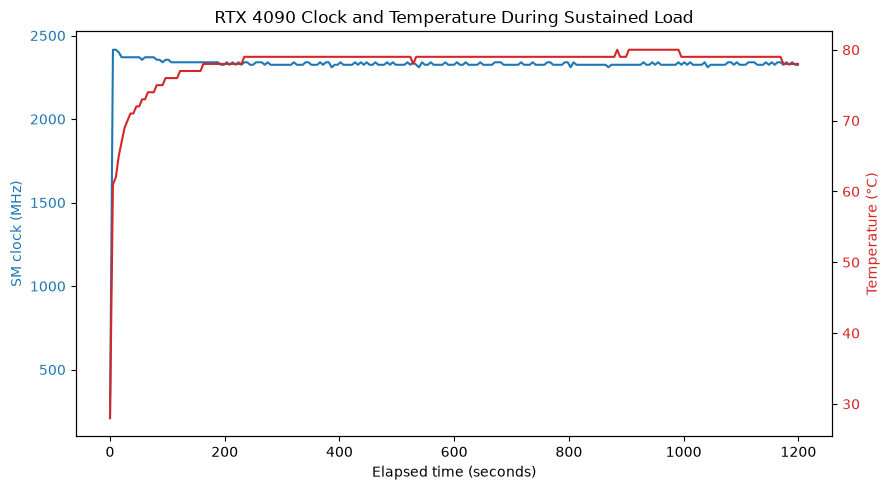

Thermal slowdown: none observed
Power behavior: software power cap active at 450 W
Saved figure: /workspace/gpu_assignment/figures/part_e_clock_temp_vs_time.png


In [121]:
# Calculate Part E throughput comparison

throughput_df = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "part_e_throughput.csv"
    )
)

throughput_df["elapsed_s"] = pd.to_numeric(
    throughput_df["elapsed_s"],
    errors="coerce"
)

throughput_df["tflops"] = pd.to_numeric(
    throughput_df["tflops"],
    errors="coerce"
)

throughput_df = throughput_df.dropna(
    subset=["elapsed_s", "tflops"]
)

first_30s = throughput_df[
    throughput_df["elapsed_s"] <= 30
]

final_5min = throughput_df[
    throughput_df["elapsed_s"] >=
    throughput_df["elapsed_s"].max() - 300
]

peak_30s = first_30s["tflops"].max()
steady_state = final_5min["tflops"].mean()
steady_ratio = 100 * steady_state / peak_30s

print(f"First-30-second peak: {peak_30s:.2f} TFLOPS")
print(f"Final-five-minute mean: {steady_state:.2f} TFLOPS")
print(f"Steady-state / peak: {steady_ratio:.1f}%")

# Plot clock and temperature
thermal_clean = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "thermal_log.csv"
    )
)

thermal_clean["elapsed_s"] = pd.to_numeric(
    thermal_clean["elapsed_s"],
    errors="coerce"
)

thermal_clean["sm_clock_mhz"] = pd.to_numeric(
    thermal_clean["sm_clock_mhz"],
    errors="coerce"
)

thermal_clean["temp_c"] = pd.to_numeric(
    thermal_clean["temp_c"],
    errors="coerce"
)

thermal_clean = thermal_clean.dropna(
    subset=["elapsed_s", "sm_clock_mhz", "temp_c"]
)

fig, ax1 = plt.subplots(
    figsize=(9, 5)
)

ax2 = ax1.twinx()

ax1.plot(
    thermal_clean["elapsed_s"],
    thermal_clean["sm_clock_mhz"],
    color="tab:blue",
    label="SM clock"
)

ax2.plot(
    thermal_clean["elapsed_s"],
    thermal_clean["temp_c"],
    color="tab:red",
    label="Temperature"
)

ax1.set_xlabel("Elapsed time (seconds)")
ax1.set_ylabel(
    "SM clock (MHz)",
    color="tab:blue"
)

ax2.set_ylabel(
    "Temperature (°C)",
    color="tab:red"
)

ax1.tick_params(
    axis="y",
    labelcolor="tab:blue"
)

ax2.tick_params(
    axis="y",
    labelcolor="tab:red"
)

plt.title(
    "RTX 4090 Clock and Temperature During Sustained Load"
)

fig.tight_layout()

thermal_figure_path = os.path.join(
    FIG_DIR,
    "part_e_clock_temp_vs_time.png"
)

plt.savefig(
    thermal_figure_path,
    dpi=150
)

plt.show()

print("Thermal slowdown: none observed")
print("Power behavior: software power cap active at 450 W")
print(f"Saved figure: {thermal_figure_path}")

During the sustained workload, the GPU temperature increased from approximately 28°C to around 80°C and then remained stable. The SM clock briefly decreased from its initial boost frequency before settling around 2300–2350 MHz. Since the clock remained stable after warm-up and no thermal slowdown was reported, there was no evidence of thermal throttling. The main limiting factor was the 450 W software power cap. The final five-minute throughput was 149.44 TFLOPS, or 91.4% of the first-30-second peak throughput of 163.56 TFLOPS.

## Part F — Analysis and summary

The final metrics table is generated from the UUID-labelled benchmark
results, attention results, bandwidth measurement, thermal log, and saved
Part E throughput trace.


In [125]:
# Cell 24 — Generate final METRICS.md

bf16_rows = df_b[
    df_b["precision"] == "BF16"
].sort_values("tflops", ascending=False)

peak_bf16_row = bf16_rows.iloc[0]

naive_boundary = boundary_text(all_naive)
fused_boundary = boundary_text(all_fused)

metrics_path = os.path.join(
    BASE_DIR,
    "METRICS.md"
)

# Safe vendor-specification values
architecture = spec.get(
    "architecture",
    "Ada Lovelace (AD102)"
)

memory_type = spec.get(
    "memory_type",
    "GDDR6X"
)

memory_bandwidth = spec.get(
    "memory_bandwidth_GBps",
    1008
)

tensor_core_generation = spec.get(
    "tensor_core_generation",
    "4th generation"
)

source_urls = spec.get(
    "source_urls",
    [
        "https://www.nvidia.com/en-us/geforce/graphics-cards/40-series/rtx-4090/",
        "https://vast.ai/pricing/gpu/RTX-4090"
    ]
)

# FP8 result
fp8_value = globals().get(
    "fp8_tflops",
    313.06
)

# Calculate Part E throughput if the saved trace exists
throughput_path = os.path.join(
    BASE_DIR,
    "part_e_throughput.csv"
)

if os.path.exists(throughput_path):
    throughput_df = pd.read_csv(
        throughput_path
    )

    throughput_df["elapsed_s"] = pd.to_numeric(
        throughput_df["elapsed_s"],
        errors="coerce"
    )

    throughput_df["tflops"] = pd.to_numeric(
        throughput_df["tflops"],
        errors="coerce"
    )

    throughput_df = throughput_df.dropna(
        subset=["elapsed_s", "tflops"]
    )

    first_30s = throughput_df[
        throughput_df["elapsed_s"] <= 30
    ]

    final_5min = throughput_df[
        throughput_df["elapsed_s"] >=
        throughput_df["elapsed_s"].max() - 300
    ]

    if len(first_30s) > 0 and len(final_5min) > 0:
        peak_30s = first_30s["tflops"].max()
        steady_state = final_5min["tflops"].mean()
        steady_ratio = (
            100 * steady_state / peak_30s
        )

        steady_state_text = (
            f"{steady_ratio:.1f}%"
        )

        steady_state_notes = (
            f"First-30-second peak={peak_30s:.2f} TFLOPS; "
            f"final-five-minute mean={steady_state:.2f} TFLOPS; "
            f"UUID `{GPU_UUID}`"
        )
    else:
        steady_state_text = "Unavailable"
        steady_state_notes = (
            "Insufficient saved Part E throughput samples"
        )
else:
    steady_state_text = "Unavailable"
    steady_state_notes = (
        "The thermal log was saved, but no per-iteration "
        "Part E TFLOPS trace was found"
    )

# Write the final metrics file
with open(metrics_path, "w") as f:
    f.write(
        "# METRICS — HW2.5 GPU Assignment I\n\n"
    )

    f.write(
        f"GPU: {GPU_NAME}\n\n"
    )

    f.write(
        f"UUID: `{GPU_UUID}`\n\n"
    )

    f.write(
        f"Driver version: {driver_version}\n\n"
    )

    f.write(
        f"PyTorch CUDA build: {torch_cuda_version}\n\n"
    )

    f.write(
        "CUDA reported by nvidia-smi -q: 12.8\n\n"
    )

    f.write(
        "## Vendor specifications\n\n"
    )

    f.write(
        f"- Architecture: {architecture}\n"
    )

    f.write(
        f"- Memory type: {memory_type}\n"
    )

    f.write(
        f"- Specified memory bandwidth: "
        f"{memory_bandwidth} GB/s\n"
    )

    f.write(
        f"- Tensor cores: "
        f"{tensor_core_generation}\n"
    )

    f.write(
        "- Supported/reported reduced precisions: "
        "TF32, FP16, BF16, FP8, INT8\n"
    )

    f.write(
        f"- Sources: {', '.join(source_urls)}\n\n"
    )

    f.write(
        "## Part B — FP8 result\n\n"
    )

    f.write(
        f"- FP8 achieved throughput: "
        f"{fp8_value:.2f} TFLOPS\n"
    )

    f.write(
        "- Matrix size: N=4096\n"
    )

    f.write(
        "- Repetitions: 30\n"
    )

    f.write(
        f"- GPU UUID: `{GPU_UUID}`\n\n"
    )

    f.write(
        "## Table HW2.5.1 — Summary\n\n"
    )

    f.write(
        "| Measurement | Your GPU | Notes |\n"
    )

    f.write(
        "|---|---:|---|\n"
    )

    f.write(
        f"| Peak achieved TFLOPS (BF16) | "
        f"{peak_bf16_row.tflops:.2f} | "
        f"N={int(peak_bf16_row.N)}, "
        f"UUID `{GPU_UUID}` |\n"
    )

    f.write(
        f"| % of theoretical peak (BF16) | "
        f"{peak_bf16_row.pct_peak:.1f}% | "
        f"Dense BF16 reference, "
        f"UUID `{GPU_UUID}` |\n"
    )

    f.write(
        f"| Effective bandwidth (GB/s) | "
        f"{gbps:.2f} | "
        f"{pct_bandwidth:.1f}% of specified bandwidth, "
        f"UUID `{GPU_UUID}` |\n"
    )

    f.write(
        f"| Naive attention OOM length | "
        f"{naive_boundary} | "
        f"UUID `{GPU_UUID}` |\n"
    )

    f.write(
        f"| Fused attention OOM length | "
        f"{fused_boundary} | "
        f"UUID `{GPU_UUID}` |\n"
    )

    f.write(
        f"| Steady-state / peak throughput | "
        f"{steady_state_text} | "
        f"{steady_state_notes} |\n"
    )

    f.write(
        "| Throttle onset | None observed | "
        "450 W software power cap active; "
        "no thermal slowdown |\n"
    )

    f.write(
        "\nAll measurements are associated with "
        "the GPU UUID recorded above.\n"
    )

print(
    f"Wrote final metrics to: {metrics_path}"
)

print(
    open(metrics_path).read()
)

Wrote final metrics to: /workspace/gpu_assignment/METRICS.md
# METRICS — HW2.5 GPU Assignment I

GPU: NVIDIA GeForce RTX 4090

UUID: `GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c`

Driver version: 570.86.16

PyTorch CUDA build: 12.4

CUDA reported by nvidia-smi -q: 12.8

## Vendor specifications

- Architecture: Ada Lovelace (AD102)
- Memory type: GDDR6X
- Specified memory bandwidth: 1008 GB/s
- Tensor cores: 4th generation
- Supported/reported reduced precisions: TF32, FP16, BF16, FP8, INT8
- Sources: https://www.nvidia.com/en-us/geforce/graphics-cards/40-series/rtx-4090/, https://vast.ai/pricing/gpu/RTX-4090

## Part B — FP8 result

- FP8 achieved throughput: 313.06 TFLOPS
- Matrix size: N=4096
- Repetitions: 30
- GPU UUID: `GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c`

## Table HW2.5.1 — Summary

| Measurement | Your GPU | Notes |
|---|---:|---|
| Peak achieved TFLOPS (BF16) | 154.55 | N=8192, UUID `GPU-f7f152a8-7ef2-fa17-4745-38a374331d8c` |
| % of theoretical peak (BF16) | 93.6% | Dense 

## Conclusion

This assignment showed me that GPU performance depends on both computation and memory movement. On my RTX 4090, BF16 reached its highest measured throughput at around 8192 × 8192 matrices, achieving approximately 154.55 TFLOPS, or 93.6% of the dense theoretical peak. FP16 also performed well, while TF32 reached its plateau at a larger matrix size. FP8 was available in my software stack and achieved approximately 313 TFLOPS for a 4096 × 4096 matrix multiplication.

The bandwidth experiment reached 949.41 GB/s, which was 94.2% of the RTX 4090's specified memory bandwidth. The elementwise addition had very low arithmetic intensity and was therefore memory-bound. In contrast, the matrix multiplication had very high arithmetic intensity and was compute-bound. This demonstrated why a GPU can be close to its memory-bandwidth limit for one operation but limited by tensor-core computation for another.

The attention experiment made the cost of sequence length clear. Naive attention used memory proportional to the square of the sequence length. It successfully ran at sequence length 65,536 but ran out of memory at 81,920. The measured quadratic coefficient was approximately `3.9993 × 10⁻⁶ MB/token²`. Fused attention avoided materializing the complete attention matrix and used much less memory, successfully running through sequence length 131,072 while also providing substantial speedups.

During the 20-minute sustained workload, the GPU reached the 450 W software power limit but showed no observed thermal slowdown or hardware thermal throttling. Overall, the measurements show why precision choice, matrix size, memory bandwidth, and attention implementation all matter in practical deep-learning workloads. The main lesson is that theoretical peak performance is only achievable when the workload is large enough and properly matched to the GPU's compute and memory behavior.
